<a href="https://colab.research.google.com/github/kosar-am/rice-classification-cnn/blob/main/notebooks/02_tensorflow_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Classification Using TensorFlow


## Install and Import Libraries

In [1]:
# Install KaggleHub to access the dataset

!pip install -q kagglehub

In [2]:
# Import required libraries

import os
import kagglehub
import tensorflow as tf

## Download Dataset

In [3]:
# Download the rice image dataset from Kaggle

dataset_path = kagglehub.dataset_download(
    "muratkokludataset/rice-image-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Dataset downloaded to:
/kaggle/input/rice-image-dataset


## Define Dataset Path

In [4]:
# Define the path to the image dataset

rice_dataset_path = os.path.join(
    dataset_path,
    "Rice_Image_Dataset"
)

print(rice_dataset_path)

/kaggle/input/rice-image-dataset/Rice_Image_Dataset


## Define Dataset Parameters

In [5]:
# Define parameters for loading the image dataset

IMAGE_SIZE = (250, 250)
BATCH_SIZE = 32
SEED = 42

## Create Training and Validation Datasets


In [6]:
# Load 80% of the images as the training dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    rice_dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 75000 files belonging to 5 classes.
Using 60000 files for training.


In [7]:
# Load 20% of the images as the validation dataset

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    rice_dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


In [8]:
print(train_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [9]:
print(validation_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## Inspect One Batch

In [11]:
# Get one batch from the training dataset

for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 250, 250, 3)
Labels shape: (32,)


## Display Images from One Batch

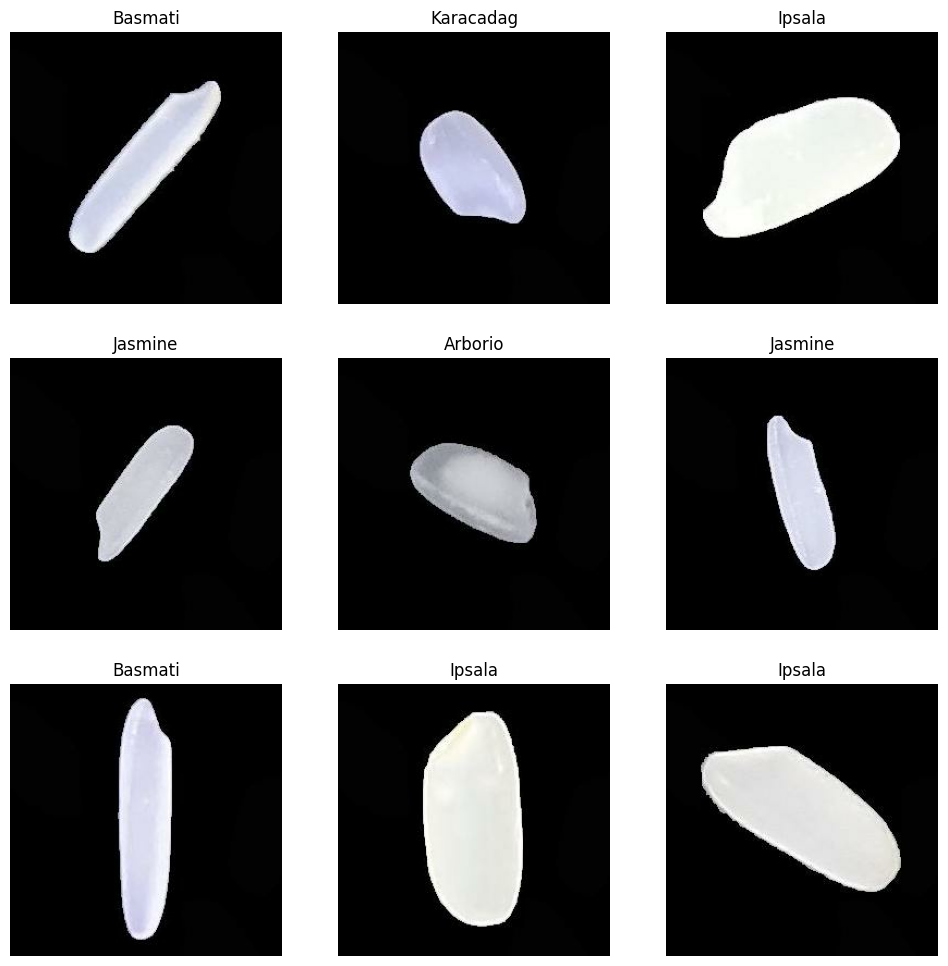

In [12]:
# Display images from the first training batch

import matplotlib.pyplot as plt

class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 12))

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

    plt.show()

## Normalize Pixel Values

In [13]:
# Create a normalization layer

normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

In [14]:
# Apply normalization to training and validation datasets

normalized_train_dataset = train_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

normalized_validation_dataset = validation_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

In [15]:
# Check pixel value range after normalization

for images, labels in normalized_train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Optimize Dataset Performance

In [16]:
# Improve data loading performance

AUTOTUNE = tf.data.AUTOTUNE

normalized_train_dataset = normalized_train_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

normalized_validation_dataset = normalized_validation_dataset.cache().prefetch(
    buffer_size=AUTOTUNE
)

## Data Augmentation

In [17]:
# Create data augmentation layers

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])